In [ ]:
import requests
from sklearn.metrics import precision_score,accuracy_score,recall_score,f1_score,classification_report,confusion_matrix,make_scorer
import io
import chess
import chess.pgn
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import pickle
!pip install pandoc
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import json
import chess.svg
from tqdm import tqdm


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
country_codes = [
    "US", "IN", "BR", "ID", "PH",
    "GB", "CA", "DE", "FR", "TR"
]
country_player_urls = {
    code: f"https://api.chess.com/pub/country/{code}/players"
    for code in country_codes
}
print(country_player_urls)

{'US': 'https://api.chess.com/pub/country/US/players', 'IN': 'https://api.chess.com/pub/country/IN/players', 'BR': 'https://api.chess.com/pub/country/BR/players', 'ID': 'https://api.chess.com/pub/country/ID/players', 'PH': 'https://api.chess.com/pub/country/PH/players', 'GB': 'https://api.chess.com/pub/country/GB/players', 'CA': 'https://api.chess.com/pub/country/CA/players', 'DE': 'https://api.chess.com/pub/country/DE/players', 'FR': 'https://api.chess.com/pub/country/FR/players', 'TR': 'https://api.chess.com/pub/country/TR/players'}


In [9]:
headers = {
    "User-Agent": "Chess_ML_Self_Assignment (kevinsbryce@gmail.com)"
}

In [7]:

player_lists = {}

for country_code, url in country_player_urls.items():
    try:
        players = requests.get(url, headers=headers).json()["players"]
        player_lists[country_code] = players
        print(f"{country_code}: {len(players)} players")
    except Exception as e:
        print(f"Failed for {country_code}: {e}")


#us_player_list = [elem["games"] for elem in feb_round_list]

US: 10000 players
IN: 10000 players
BR: 10000 players
ID: 10000 players
PH: 10000 players
GB: 10000 players
CA: 10000 players
DE: 10000 players
FR: 10000 players
TR: 10000 players


In [10]:
import time

player_stats = {}

processed = 0

for players in player_lists.values():
    for username in players:
        processed += 1

        try:
            response = requests.get(
                f"https://api.chess.com/pub/player/{username}/stats",
                headers=headers
            )

            stats = response.json()

            if "chess_rapid" not in stats:
                continue

            rapid_stats = stats["chess_rapid"]

            player_stats[username] = {
                "rating": rapid_stats["last"]["rating"],
                "rating_deviation": rapid_stats["last"]["rd"],
                "last_played": rapid_stats["last"]["date"],
                "total_games": (
                    rapid_stats["record"]["win"]
                    + rapid_stats["record"]["loss"]
                    + rapid_stats["record"]["draw"]
                ),
            }

            if processed % 50 == 0:
                print(
                    f"Processed {processed:,} players | "
                    f"Stored {len(player_stats):,} rapid players"
                )

            #time.sleep(0.1)

        except Exception as e:
            print(f"Failed for {username}: {e}")

Processed 50 players | Stored 47 rapid players
Processed 100 players | Stored 90 rapid players
Processed 150 players | Stored 135 rapid players
Failed for 007zim: 'rd'
Processed 250 players | Stored 224 rapid players
Processed 300 players | Stored 270 rapid players
Processed 350 players | Stored 313 rapid players
Processed 400 players | Stored 358 rapid players
Processed 450 players | Stored 404 rapid players
Failed for 01bella4951hk: 'rd'
Processed 500 players | Stored 448 rapid players
Processed 550 players | Stored 490 rapid players
Processed 600 players | Stored 534 rapid players
Processed 650 players | Stored 577 rapid players
Processed 700 players | Stored 623 rapid players
Failed for 06yay90: 'rd'
Failed for 0770nick: 'rd'
Processed 750 players | Stored 665 rapid players
Processed 850 players | Stored 757 rapid players
Processed 900 players | Stored 801 rapid players
Processed 950 players | Stored 845 rapid players
Processed 1,000 players | Stored 891 rapid players
Processed 1,0

In [12]:
import json
with open("chess_player_stats.json", "w") as f:
    json.dump(player_stats, f)

In [11]:
with open("chess_player_stats.json", "rb") as f:
    player_stats = json.load(f)

In [13]:
chess_player_df = pd.DataFrame.from_dict(player_stats, orient="index").reset_index()

In [45]:
chess_player_df.head(10)

,index,rating,rating_deviation,last_played,total_games
0,--untouchable--,1480,201,1719629692,18
1,-bees-,2206,30,1630895322,484
2,-cpm-,1278,35,1780319823,5894
3,-death-,1016,107,1743025980,79
4,-drake,1420,189,1716169323,19
5,-dua,1018,234,1627953233,2
6,-g-,1770,60,1770695126,7772
7,-jg-,1188,47,1779640611,1324
8,-kingofthecastle-,1626,208,1762579964,84
9,-mega-,681,99,1780000422,41


In [16]:
chess_player_df.describe()

,rating,rating_deviation,last_played,total_games
count,92691.000000,92691.000000,9.269100e+04,92691.000000
mean,733.227465,80.454791,1.772051e+09,827.208327
std,437.157182,59.448202,2.403343e+07,1978.348454
min,100.000000,14.000000,1.259036e+09,1.000000
25%,393.000000,38.000000,1.776511e+09,31.000000
50%,658.000000,58.000000,1.780146e+09,186.000000
75%,1003.000000,103.000000,1.780302e+09,757.000000
max,2709.000000,349.000000,1.780384e+09,66856.000000


In [15]:
chess_player_df[
    chess_player_df["rating"].between(900, 1100)
    & (chess_player_df["rating_deviation"] <= 100)
    & (chess_player_df["total_games"] >= 50)
].count()

index               7756
rating              7756
rating_deviation    7756
last_played         7756
total_games         7756
dtype: int64

In [17]:
chess_player_df[
    chess_player_df["rating"].between(900, 1100)
    & (chess_player_df["rating_deviation"] <= 100)
    & (chess_player_df["total_games"] >= 50)
].count()

index               7756
rating              7756
rating_deviation    7756
last_played         7756
total_games         7756
dtype: int64

In [19]:
filtered = chess_player_df[
    chess_player_df["rating"].between(900, 1100)
    & (chess_player_df["rating_deviation"] <= 100)
    & (chess_player_df["total_games"] >= 50)
]

filtered["total_games"].describe()

count     7756.000000
mean      1615.260701
std       2459.521916
min         50.000000
25%        324.000000
50%        849.500000
75%       1899.000000
max      66856.000000
Name: total_games, dtype: float64

In [57]:
filtered_2k = chess_player_df[
    chess_player_df["rating"].between(1900, 2100)
    & (chess_player_df["rating_deviation"] <= 100)
    & (chess_player_df["total_games"] >= 50)
]

filtered_2k["total_games"].describe()

count      722.000000
mean      2902.008310
std       4696.624275
min         51.000000
25%        397.000000
50%       1117.000000
75%       3517.000000
max      53013.000000
Name: total_games, dtype: float64

In [12]:
filtered["total_games"].quantile([
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99,
    0.999
])

0.250      324.00
0.500      849.50
0.750     1899.00
0.900     3806.00
0.950     5774.75
0.990    11821.95
0.999    21864.79
Name: total_games, dtype: float64

In [58]:
filtered_2k["total_games"].quantile([
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99,
    0.999
])

0.250      397.000
0.500     1117.000
0.750     3517.000
0.900     7843.800
0.950    10564.400
0.990    21933.330
0.999    41540.448
Name: total_games, dtype: float64

In [13]:
print(len(filtered))
print(filtered["total_games"].sum())

7756
12527962


In [31]:
filtered.to_csv("1000-elo-chess-players.csv", index=False)

In [59]:
filtered_2k.to_csv("2000-elo-chess-players.csv", index=False)

In [21]:
first_five_hundred = filtered["index"].values[:500]

In [60]:
first_five_hundred_2k = filtered_2k["index"].values[:500]

In [23]:
five_hundo_archive_list = {}
for username in first_five_hundred:
    print(f"Processing: {username} archives")
    response = requests.get(f"https://api.chess.com/pub/player/{username}/games/archives", headers=headers).json()
    
    archives = response.get("archives", [])
    
    five_hundo_archive_list[username] = archives[-24:]

Processing: 0-queentheking-0 archives
Processing: 0-sicknasty archives
Processing: 001theone001 archives
Processing: 003yoony archives
Processing: 007bbond archives
Processing: 007hitman archives
Processing: 007jnv archives
Processing: 00jakethesnake archives
Processing: 00kane00 archives
Processing: 00nu archives
Processing: 00pp0ggggggg archives
Processing: 00profit archives
Processing: 00ramen00 archives
Processing: 00rocky03 archives
Processing: 00slater archives
Processing: 00uhtred archives
Processing: 01294030b archives
Processing: 012brokenbird210 archives
Processing: 018stockfish archives
Processing: 01chesslover48 archives
Processing: 01pqla archives
Processing: 02vettez06 archives
Processing: 0309h archives
Processing: 036torreado archives
Processing: 03generalzod51 archives
Processing: 03hjo archives
Processing: 03sheep archives
Processing: 04c240 archives
Processing: 05th archives
Processing: 07londonisred archives
Processing: 084shield archives
Processing: 089x archives
P

In [62]:
five_hundo_2k_archive_list = {}
for username in first_five_hundred_2k:
    print(f"Processing: {username} archives")
    response = requests.get(f"https://api.chess.com/pub/player/{username}/games/archives", headers=headers).json()
    
    archives = response.get("archives", [])
    
    five_hundo_2k_archive_list[username] = archives[-24:]

Processing: -redak- archives
Processing: 00gab00gah archives
Processing: 0k_kugelblitz archives
Processing: 0llave archives
Processing: 0riginal_yanko archives
Processing: 0wen530 archives
Processing: 100aces archives
Processing: 100percentsatisfaction archives
Processing: 10_bob_note archives
Processing: 123duke123 archives
Processing: 123full archives
Processing: 123goat456 archives
Processing: 123staples archives
Processing: 12shaxmat archives
Processing: 1313stuart archives
Processing: 13taylor archives
Processing: 16andstiles archives
Processing: 17dsoto archives
Processing: 17thpiece archives
Processing: 19meyerowitzs archives
Processing: 1amnotanumber archives
Processing: 1b4_wins archives
Processing: 1chrisandrews archives
Processing: 1cqhueesesn1 archives
Processing: 1elliot archives
Processing: 1enpassant archives
Processing: 1knight_rider1 archives
Processing: 1miranova archives
Processing: 1mortar archives
Processing: 1mprovingmychess archives
Processing: 1r00kie archives
P

In [35]:
five_hundo_archive_list["0-queentheking-0"]

['https://api.chess.com/pub/player/0-queentheking-0/games/2025/04',
 'https://api.chess.com/pub/player/0-queentheking-0/games/2025/05',
 'https://api.chess.com/pub/player/0-queentheking-0/games/2025/06',
 'https://api.chess.com/pub/player/0-queentheking-0/games/2025/07',
 'https://api.chess.com/pub/player/0-queentheking-0/games/2025/08',
 'https://api.chess.com/pub/player/0-queentheking-0/games/2025/09',
 'https://api.chess.com/pub/player/0-queentheking-0/games/2025/10',
 'https://api.chess.com/pub/player/0-queentheking-0/games/2025/11',
 'https://api.chess.com/pub/player/0-queentheking-0/games/2025/12',
 'https://api.chess.com/pub/player/0-queentheking-0/games/2026/01',
 'https://api.chess.com/pub/player/0-queentheking-0/games/2026/02',
 'https://api.chess.com/pub/player/0-queentheking-0/games/2026/03',
 'https://api.chess.com/pub/player/0-queentheking-0/games/2026/04',
 'https://api.chess.com/pub/player/0-queentheking-0/games/2026/05']

In [24]:
training_data = {}

MIN_RATING = 900
MAX_RATING = 1100
MAX_GAMES_PER_PLAYER = 800
processed_players = 0
for username, archive_urls in five_hundo_archive_list.items():
    processed_players += 1

    print(
        f"Processing player "
        f"{processed_players}/{len(five_hundo_archive_list)}: "
        f"{username}"
    )

    training_data[username] = []
    games_recorded = 0

    for archive_url in archive_urls:

        if games_recorded >= MAX_GAMES_PER_PLAYER:
            break

        try:
            archive = requests.get(
                archive_url,
                headers=headers,
                timeout=15
            ).json()

            games = archive.get("games", [])

            for game in games:

                if games_recorded >= MAX_GAMES_PER_PLAYER:
                    break

                # Standard chess only
                if game.get("rules") != "chess":
                    continue

                # Rated games only
                if not game.get("rated", False):
                    continue

                # Rapid games only
                if game.get("time_class") != "rapid":
                    continue

                white_rating = game["white"]["rating"]
                black_rating = game["black"]["rating"]

                # Only keep games where BOTH players are 900-1100
                if not (
                    MIN_RATING <= white_rating <= MAX_RATING
                    and
                    MIN_RATING <= black_rating <= MAX_RATING
                ):
                    continue

                training_data[username].append({
                    "white_username": game["white"]["username"],
                    "black_username": game["black"]["username"],
                    "white_rating": white_rating,
                    "black_rating": black_rating,
                    "time_class": game["time_class"],
                    "time_control": game["time_control"],
                    "rated": game["rated"],
                    "rules": game["rules"],
                    "end_time": game["end_time"],
                    "url": game["url"],
                    "pgn": game["pgn"]
                })

                games_recorded += 1

        except Exception as e:
            print(f"Failed {archive_url}: {e}")

    print(
        f"{username}: collected {games_recorded} qualifying games"
    )
    # Checkpoint every 50 players
    if processed_players % 50 == 0:

        checkpoint_file = (
            f"training_data_checkpoint_"
            f"{processed_players}.json"
        )

        with open(checkpoint_file, "w") as f:
            json.dump(training_data, f)

        print(
            f"Checkpoint saved: {checkpoint_file}"
        )

with open("training_data_final.json", "w") as f:
    json.dump(training_data, f)

print("Final save complete")

Processing player 1/500: 0-queentheking-0
0-queentheking-0: collected 31 qualifying games
Processing player 2/500: 0-sicknasty
0-sicknasty: collected 324 qualifying games
Processing player 3/500: 001theone001
001theone001: collected 70 qualifying games
Processing player 4/500: 003yoony
003yoony: collected 93 qualifying games
Processing player 5/500: 007bbond
007bbond: collected 800 qualifying games
Processing player 6/500: 007hitman
007hitman: collected 800 qualifying games
Processing player 7/500: 007jnv
007jnv: collected 800 qualifying games
Processing player 8/500: 00jakethesnake
00jakethesnake: collected 45 qualifying games
Processing player 9/500: 00kane00
00kane00: collected 800 qualifying games
Processing player 10/500: 00nu
00nu: collected 613 qualifying games
Processing player 11/500: 00pp0ggggggg
00pp0ggggggg: collected 123 qualifying games
Processing player 12/500: 00profit
00profit: collected 800 qualifying games
Processing player 13/500: 00ramen00
00ramen00: collected 131 

In [65]:
training_data_2000 = {}

MIN_RATING = 1900
MAX_RATING = 2100
MAX_GAMES_PER_PLAYER = 1000
processed_players = 0
for username, archive_urls in five_hundo_2k_archive_list.items():
    processed_players += 1

    print(
        f"Processing player "
        f"{processed_players}/{len(five_hundo_2k_archive_list)}: "
        f"{username}"
    )

    training_data_2000[username] = []
    games_recorded = 0

    for archive_url in archive_urls:

        if games_recorded >= MAX_GAMES_PER_PLAYER:
            break

        try:
            archive = requests.get(
                archive_url,
                headers=headers,
                timeout=15
            ).json()

            games = archive.get("games", [])

            for game in games:

                if games_recorded >= MAX_GAMES_PER_PLAYER:
                    break

                # Standard chess only
                if game.get("rules") != "chess":
                    continue

                # Rated games only
                if not game.get("rated", False):
                    continue

                # Rapid games only
                if game.get("time_class") != "rapid":
                    continue

                white_rating = game["white"]["rating"]
                black_rating = game["black"]["rating"]

                # Only keep games where BOTH players are 900-1100
                if not (
                    MIN_RATING <= white_rating <= MAX_RATING
                    and
                    MIN_RATING <= black_rating <= MAX_RATING
                ):
                    continue

                training_data_2000[username].append({
                    "white_username": game["white"]["username"],
                    "black_username": game["black"]["username"],
                    "white_rating": white_rating,
                    "black_rating": black_rating,
                    "time_class": game["time_class"],
                    "time_control": game["time_control"],
                    "rated": game["rated"],
                    "rules": game["rules"],
                    "end_time": game["end_time"],
                    "url": game["url"],
                    "pgn": game["pgn"]
                })

                games_recorded += 1

        except Exception as e:
            print(f"Failed {archive_url}: {e}")

    print(
        f"{username}: collected {games_recorded} qualifying games"
    )
    # Checkpoint every 50 players
    if processed_players % 50 == 0:

        checkpoint_file = (
            f"training_data_2000_checkpoint_"
            f"{processed_players}.json"
        )

        with open(checkpoint_file, "w") as f:
            json.dump(training_data_2000, f)

        print(
            f"Checkpoint saved: {checkpoint_file}"
        )

with open("training_data_2000_final.json", "w") as f:
    json.dump(training_data_2000, f)

print("Final save complete")

Processing player 1/500: -redak-
-redak-: collected 23 qualifying games
Processing player 2/500: 00gab00gah
00gab00gah: collected 479 qualifying games
Processing player 3/500: 0k_kugelblitz
0k_kugelblitz: collected 5 qualifying games
Processing player 4/500: 0llave
0llave: collected 174 qualifying games
Processing player 5/500: 0riginal_yanko
0riginal_yanko: collected 124 qualifying games
Processing player 6/500: 0wen530
0wen530: collected 0 qualifying games
Processing player 7/500: 100aces
100aces: collected 60 qualifying games
Processing player 8/500: 100percentsatisfaction
100percentsatisfaction: collected 25 qualifying games
Processing player 9/500: 10_bob_note
10_bob_note: collected 2 qualifying games
Processing player 10/500: 123duke123
123duke123: collected 1000 qualifying games
Processing player 11/500: 123full
123full: collected 485 qualifying games
Processing player 12/500: 123goat456
123goat456: collected 1000 qualifying games
Processing player 13/500: 123staples
123staples:

In [6]:
with open("training_data_checkpoint_500.json", "r") as f:
     training_data = json.load(f)

UnsupportedOperation: not readable

In [ ]:
with open("training_data_2000_final.json", "r") as f:
     training_data_2000 = json.load(f)

In [29]:
rows = []
for archive_owner, games in training_data.items():

    for game in games:

        row = game.copy()
        row["archive_owner"] = archive_owner

        rows.append(row)

games_df = pd.DataFrame(rows)

In [67]:
rows_2k = []
for archive_owner, games in training_data_2000.items():

    for game in games:

        row = game.copy()
        row["archive_owner"] = archive_owner

        rows_2k.append(row)

games_df_2k = pd.DataFrame(rows_2k)

In [42]:
print(games_df.count())
games_df.head(10)

white_username    161091
black_username    161091
white_rating      161091
black_rating      161091
time_class        161091
time_control      161091
rated             161091
rules             161091
end_time          161091
url               161091
pgn               161091
archive_owner     161091
dtype: int64


,white_username,black_username,white_rating,black_rating,time_class,time_control,rated,rules,end_time,url,pgn,archive_owner
0,0-QueenTheKing-0,lmDrunk,913,916,rapid,600,True,chess,1762301454,https://www.chess.com/game/live/145127116586,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",0-queentheking-0
1,Emesya91,0-QueenTheKing-0,913,905,rapid,600,True,chess,1762302672,https://www.chess.com/game/live/145127289208,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",0-queentheking-0
2,0-QueenTheKing-0,getgoudnoob,905,916,rapid,600,True,chess,1762871055,https://www.chess.com/game/live/145384449366,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",0-queentheking-0
3,0-QueenTheKing-0,builders87,905,914,rapid,600,True,chess,1762872827,https://www.chess.com/game/live/145385211924,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",0-queentheking-0
4,0-QueenTheKing-0,showmedamoney0,905,918,rapid,600,True,chess,1763335227,https://www.chess.com/game/live/145600234524,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",0-queentheking-0
5,0-QueenTheKing-0,KHALEDNABIL0,921,902,rapid,600,True,chess,1763388457,https://www.chess.com/game/live/145620958454,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",0-queentheking-0
6,guigui13500,0-QueenTheKing-0,918,913,rapid,600,True,chess,1763418530,https://www.chess.com/game/live/145638918420,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",0-queentheking-0
7,0-QueenTheKing-0,chessyPhilleep,905,925,rapid,600,True,chess,1763419414,https://www.chess.com/game/live/145639010402,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",0-queentheking-0
8,0-QueenTheKing-0,Mo_200000,905,912,rapid,600,True,chess,1763559551,https://www.chess.com/game/live/145700468496,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",0-queentheking-0
9,Lillebos,0-QueenTheKing-0,926,910,rapid,600,True,chess,1764455353,https://www.chess.com/game/live/146120213524,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",0-queentheking-0


In [68]:
print(games_df_2k.count())
games_df_2k.head(10)

white_username    182577
black_username    182577
white_rating      182577
black_rating      182577
time_class        182577
time_control      182577
rated             182577
rules             182577
end_time          182577
url               182577
pgn               182577
archive_owner     182577
dtype: int64


,white_username,black_username,white_rating,black_rating,time_class,time_control,rated,rules,end_time,url,pgn,archive_owner
0,-redak-,RRandomSoul,1956,1929,rapid,600,True,chess,1761554362,https://www.chess.com/game/live/144783646436,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",-redak-
1,-redak-,leonid195020,1956,1955,rapid,600,True,chess,1761555256,https://www.chess.com/game/live/144783759552,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",-redak-
2,-redak-,janskak12,1980,1926,rapid,600,True,chess,1761555798,https://www.chess.com/game/live/144784186618,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",-redak-
3,mattyangelo,-redak-,1953,2002,rapid,600,True,chess,1761556648,https://www.chess.com/game/live/144784440300,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",-redak-
4,Miskan110914,-redak-,2033,1995,rapid,600,True,chess,1761585024,https://www.chess.com/game/live/144800482344,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",-redak-
5,-redak-,dr_wise1,2003,1968,rapid,600,True,chess,1761634263,https://www.chess.com/game/live/144821180150,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",-redak-
6,Askar_Turarbekov,-redak-,1979,1994,rapid,600,True,chess,1761636695,https://www.chess.com/game/live/144822304462,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",-redak-
7,-redak-,MarioCQ,1986,1992,rapid,600,True,chess,1761658151,https://www.chess.com/game/live/144832626834,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",-redak-
8,kjan54,-redak-,1986,1994,rapid,600,True,chess,1761665009,https://www.chess.com/game/live/144837195014,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",-redak-
9,-redak-,xuanquangtran,1986,1987,rapid,600,True,chess,1761720189,https://www.chess.com/game/live/144861446304,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",-redak-


In [31]:
training_moves = []
counter = 0
for idx, row in enumerate(games_df.itertuples(index=False)):
    
    if idx % 1000 == 0:
        print(f"Processing game {idx:,}")

    average_rating = (
        row.white_rating + row.black_rating
    ) / 2

    game = chess.pgn.read_game(io.StringIO(row.pgn))
    board = game.board()

    for move in game.mainline_moves():

        current_position = board.fen()

        board.push(move)

        next_position = board.fen()

        training_moves.append({
            "current_position": current_position,
            "next_position": next_position,
            "move": move.uci(),
            "average_rating": average_rating,
            "url": row.url
        })

positions_df = pd.DataFrame(training_moves)

Processing game 0
Processing game 1,000
Processing game 2,000
Processing game 3,000
Processing game 4,000
Processing game 5,000
Processing game 6,000
Processing game 7,000
Processing game 8,000
Processing game 9,000
Processing game 10,000
Processing game 11,000
Processing game 12,000
Processing game 13,000
Processing game 14,000
Processing game 15,000
Processing game 16,000
Processing game 17,000
Processing game 18,000
Processing game 19,000
Processing game 20,000
Processing game 21,000
Processing game 22,000
Processing game 23,000
Processing game 24,000
Processing game 25,000
Processing game 26,000
Processing game 27,000
Processing game 28,000
Processing game 29,000
Processing game 30,000
Processing game 31,000
Processing game 32,000
Processing game 33,000
Processing game 34,000
Processing game 35,000
Processing game 36,000
Processing game 37,000
Processing game 38,000
Processing game 39,000
Processing game 40,000
Processing game 41,000
Processing game 42,000
Processing game 43,000
Pr

In [70]:
training_moves_2k = []
counter = 0
for idx, row in enumerate(games_df_2k.itertuples(index=False)):
    
    if idx % 1000 == 0:
        print(f"Processing game {idx:,}")

    average_rating = (
        row.white_rating + row.black_rating
    ) / 2

    game = chess.pgn.read_game(io.StringIO(row.pgn))
    board = game.board()

    for move in game.mainline_moves():

        current_position = board.fen()

        board.push(move)

        next_position = board.fen()

        training_moves_2k.append({
            "current_position": current_position,
            "next_position": next_position,
            "move": move.uci(),
            "average_rating": average_rating,
            "url": row.url
        })

positions_df_2k = pd.DataFrame(training_moves_2k)

Processing game 0
Processing game 1,000
Processing game 2,000
Processing game 3,000
Processing game 4,000
Processing game 5,000
Processing game 6,000
Processing game 7,000
Processing game 8,000
Processing game 9,000
Processing game 10,000
Processing game 11,000
Processing game 12,000
Processing game 13,000
Processing game 14,000
Processing game 15,000
Processing game 16,000
Processing game 17,000
Processing game 18,000
Processing game 19,000
Processing game 20,000
Processing game 21,000
Processing game 22,000
Processing game 23,000
Processing game 24,000
Processing game 25,000
Processing game 26,000
Processing game 27,000
Processing game 28,000
Processing game 29,000
Processing game 30,000
Processing game 31,000
Processing game 32,000
Processing game 33,000
Processing game 34,000
Processing game 35,000
Processing game 36,000
Processing game 37,000
Processing game 38,000
Processing game 39,000
Processing game 40,000
Processing game 41,000
Processing game 42,000
Processing game 43,000
Pr

In [54]:
positions_df.head(10)

,current_position,next_position,move,average_rating,url
0,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,e2e4,914.5,https://www.chess.com/game/live/145127116586
1,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,rnbqkbnr/pppp1ppp/8/4p3/4P3/8/PPPP1PPP/RNBQKBN...,e7e5,914.5,https://www.chess.com/game/live/145127116586
2,rnbqkbnr/pppp1ppp/8/4p3/4P3/8/PPPP1PPP/RNBQKBN...,rnbqkbnr/pppp1ppp/8/4p3/4P3/5N2/PPPP1PPP/RNBQK...,g1f3,914.5,https://www.chess.com/game/live/145127116586
3,rnbqkbnr/pppp1ppp/8/4p3/4P3/5N2/PPPP1PPP/RNBQK...,r1bqkbnr/pppp1ppp/2n5/4p3/4P3/5N2/PPPP1PPP/RNB...,b8c6,914.5,https://www.chess.com/game/live/145127116586
4,r1bqkbnr/pppp1ppp/2n5/4p3/4P3/5N2/PPPP1PPP/RNB...,r1bqkbnr/pppp1ppp/2n5/4p3/4P3/2N2N2/PPPP1PPP/R...,b1c3,914.5,https://www.chess.com/game/live/145127116586
5,r1bqkbnr/pppp1ppp/2n5/4p3/4P3/2N2N2/PPPP1PPP/R...,r1bqkbnr/ppp2ppp/2np4/4p3/4P3/2N2N2/PPPP1PPP/R...,d7d6,914.5,https://www.chess.com/game/live/145127116586
6,r1bqkbnr/ppp2ppp/2np4/4p3/4P3/2N2N2/PPPP1PPP/R...,r1bqkbnr/ppp2ppp/2np4/4p3/2B1P3/2N2N2/PPPP1PPP...,f1c4,914.5,https://www.chess.com/game/live/145127116586
7,r1bqkbnr/ppp2ppp/2np4/4p3/2B1P3/2N2N2/PPPP1PPP...,r1bqkb1r/ppp2ppp/2np1n2/4p3/2B1P3/2N2N2/PPPP1P...,g8f6,914.5,https://www.chess.com/game/live/145127116586
8,r1bqkb1r/ppp2ppp/2np1n2/4p3/2B1P3/2N2N2/PPPP1P...,r1bqkb1r/ppp2ppp/2np1n2/4p1N1/2B1P3/2N5/PPPP1P...,f3g5,914.5,https://www.chess.com/game/live/145127116586
9,r1bqkb1r/ppp2ppp/2np1n2/4p1N1/2B1P3/2N5/PPPP1P...,r2qkb1r/ppp2ppp/2npbn2/4p1N1/2B1P3/2N5/PPPP1PP...,c8e6,914.5,https://www.chess.com/game/live/145127116586


Row 0


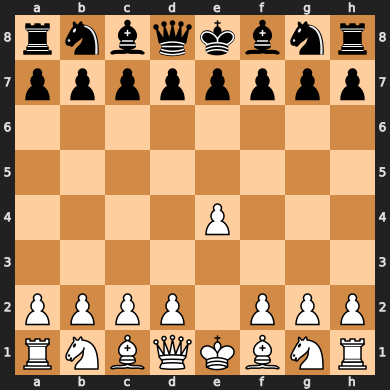

Row 1


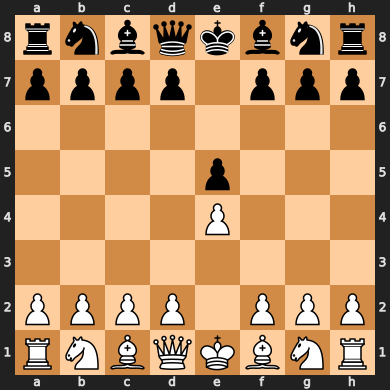

Row 2


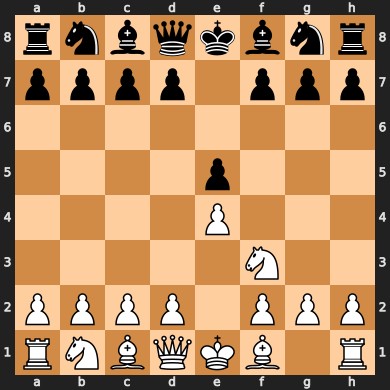

Row 3


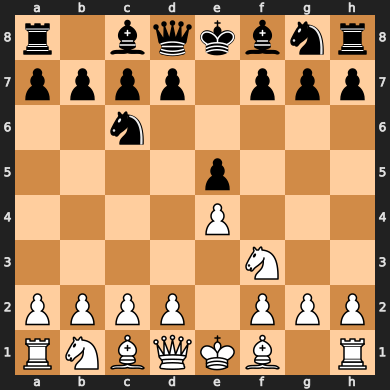

Row 4


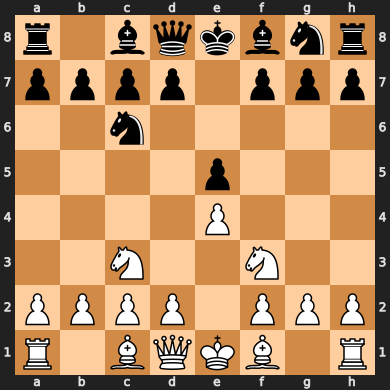

In [55]:
from IPython.display import SVG, display
import chess.svg

for i, fen in enumerate(
    positions_df["next_position"].head(5)
):

    print(f"Row {i}")

    board = chess.Board(fen)

    display(
        SVG(
            chess.svg.board(board=board)
        )
    )

In [56]:
positions_df.count()

current_position    10682091
next_position       10682091
move                10682091
average_rating      10682091
url                 10682091
dtype: int64

In [32]:
def board_to_tokens(fen):

    board = chess.Board(fen)

    tokens = []

    for square in chess.SQUARES:

        piece = board.piece_at(square)
    
        if piece is None:
            tokens.append(0)

        else:

            offset = 0 if piece.color == chess.WHITE else 6

            tokens.append(
                piece.piece_type + offset
            )

    tokens.extend([
        13 if board.turn == chess.WHITE else 14,
    
        15 if board.has_kingside_castling_rights(chess.WHITE) else 16,
        17 if board.has_queenside_castling_rights(chess.WHITE) else 18,
    
        19 if board.has_kingside_castling_rights(chess.BLACK) else 20,
        21 if board.has_queenside_castling_rights(chess.BLACK) else 22
    ])

    return tokens

In [33]:
positions_df["board_tokens"] = (
    positions_df["current_position"]
    .apply(board_to_tokens)
)

In [74]:
positions_df_2k["board_tokens"] = (
    positions_df_2k["current_position"]
    .apply(board_to_tokens)
)

In [60]:
positions_df.head(10)

,current_position,next_position,move,average_rating,url,board_tokens
0,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,e2e4,914.5,https://www.chess.com/game/live/145127116586,"[4, 2, 3, 5, 6, 3, 2, 4, 1, 1, 1, 1, 1, 1, 1, ..."
1,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,rnbqkbnr/pppp1ppp/8/4p3/4P3/8/PPPP1PPP/RNBQKBN...,e7e5,914.5,https://www.chess.com/game/live/145127116586,"[4, 2, 3, 5, 6, 3, 2, 4, 1, 1, 1, 1, 0, 1, 1, ..."
2,rnbqkbnr/pppp1ppp/8/4p3/4P3/8/PPPP1PPP/RNBQKBN...,rnbqkbnr/pppp1ppp/8/4p3/4P3/5N2/PPPP1PPP/RNBQK...,g1f3,914.5,https://www.chess.com/game/live/145127116586,"[4, 2, 3, 5, 6, 3, 2, 4, 1, 1, 1, 1, 0, 1, 1, ..."
3,rnbqkbnr/pppp1ppp/8/4p3/4P3/5N2/PPPP1PPP/RNBQK...,r1bqkbnr/pppp1ppp/2n5/4p3/4P3/5N2/PPPP1PPP/RNB...,b8c6,914.5,https://www.chess.com/game/live/145127116586,"[4, 2, 3, 5, 6, 3, 0, 4, 1, 1, 1, 1, 0, 1, 1, ..."
4,r1bqkbnr/pppp1ppp/2n5/4p3/4P3/5N2/PPPP1PPP/RNB...,r1bqkbnr/pppp1ppp/2n5/4p3/4P3/2N2N2/PPPP1PPP/R...,b1c3,914.5,https://www.chess.com/game/live/145127116586,"[4, 2, 3, 5, 6, 3, 0, 4, 1, 1, 1, 1, 0, 1, 1, ..."
5,r1bqkbnr/pppp1ppp/2n5/4p3/4P3/2N2N2/PPPP1PPP/R...,r1bqkbnr/ppp2ppp/2np4/4p3/4P3/2N2N2/PPPP1PPP/R...,d7d6,914.5,https://www.chess.com/game/live/145127116586,"[4, 0, 3, 5, 6, 3, 0, 4, 1, 1, 1, 1, 0, 1, 1, ..."
6,r1bqkbnr/ppp2ppp/2np4/4p3/4P3/2N2N2/PPPP1PPP/R...,r1bqkbnr/ppp2ppp/2np4/4p3/2B1P3/2N2N2/PPPP1PPP...,f1c4,914.5,https://www.chess.com/game/live/145127116586,"[4, 0, 3, 5, 6, 3, 0, 4, 1, 1, 1, 1, 0, 1, 1, ..."
7,r1bqkbnr/ppp2ppp/2np4/4p3/2B1P3/2N2N2/PPPP1PPP...,r1bqkb1r/ppp2ppp/2np1n2/4p3/2B1P3/2N2N2/PPPP1P...,g8f6,914.5,https://www.chess.com/game/live/145127116586,"[4, 0, 3, 5, 6, 0, 0, 4, 1, 1, 1, 1, 0, 1, 1, ..."
8,r1bqkb1r/ppp2ppp/2np1n2/4p3/2B1P3/2N2N2/PPPP1P...,r1bqkb1r/ppp2ppp/2np1n2/4p1N1/2B1P3/2N5/PPPP1P...,f3g5,914.5,https://www.chess.com/game/live/145127116586,"[4, 0, 3, 5, 6, 0, 0, 4, 1, 1, 1, 1, 0, 1, 1, ..."
9,r1bqkb1r/ppp2ppp/2np1n2/4p1N1/2B1P3/2N5/PPPP1P...,r2qkb1r/ppp2ppp/2npbn2/4p1N1/2B1P3/2N5/PPPP1PP...,c8e6,914.5,https://www.chess.com/game/live/145127116586,"[4, 0, 3, 5, 6, 0, 0, 4, 1, 1, 1, 1, 0, 1, 1, ..."


In [26]:
import chess

all_moves = set()

squares = [chess.square_name(sq) for sq in chess.SQUARES]

# Normal moves
for from_sq in squares:
    for to_sq in squares:

        if from_sq != to_sq:

            all_moves.add(
                from_sq + to_sq
            )

# Promotions
promotion_pieces = ["q", "r", "b", "n"]

for file in "abcdefgh":

    # White promotions
    for promo in promotion_pieces:

        all_moves.add(
            f"{file}7{file}8{promo}"
        )

        if file != "a":
            left_file = chr(ord(file) - 1)

            all_moves.add(
                f"{file}7{left_file}8{promo}"
            )

        if file != "h":
            right_file = chr(ord(file) + 1)

            all_moves.add(
                f"{file}7{right_file}8{promo}"
            )

    # Black promotions
    for promo in promotion_pieces:

        all_moves.add(
            f"{file}2{file}1{promo}"
        )

        if file != "a":
            left_file = chr(ord(file) - 1)

            all_moves.add(
                f"{file}2{left_file}1{promo}"
            )

        if file != "h":
            right_file = chr(ord(file) + 1)

            all_moves.add(
                f"{file}2{right_file}1{promo}"
            )

all_moves = sorted(all_moves)

print(len(all_moves))

4208


In [5]:
with open(
    "all_moves.json",
    "w"
) as f:

    json.dump(
        all_moves,
        f
    )

In [34]:
move_to_id = {
    move: idx
    for idx, move in enumerate(all_moves)
}

id_to_move = {
    idx: move
    for move, idx in move_to_id.items()
}

In [35]:
positions_df["move_id"] = (
    positions_df["move"]
    .map(move_to_id)
)

In [91]:
positions_df_2k["move_id"] = (
    positions_df_2k["move"]
    .map(move_to_id)
)

In [63]:
positions_df.head(10)

,current_position,next_position,move,average_rating,url,board_tokens,move_id
0,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,e2e4,914.5,https://www.chess.com/game/live/145127116586,"[4, 2, 3, 5, 6, 3, 2, 4, 1, 1, 1, 1, 1, 1, 1, ...",1012
1,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,rnbqkbnr/pppp1ppp/8/4p3/4P3/8/PPPP1PPP/RNBQKBN...,e7e5,914.5,https://www.chess.com/game/live/145127116586,"[4, 2, 3, 5, 6, 3, 2, 4, 1, 1, 1, 1, 0, 1, 1, ...",1186
2,rnbqkbnr/pppp1ppp/8/4p3/4P3/8/PPPP1PPP/RNBQKBN...,rnbqkbnr/pppp1ppp/8/4p3/4P3/5N2/PPPP1PPP/RNBQK...,g1f3,914.5,https://www.chess.com/game/live/145127116586,"[4, 2, 3, 5, 6, 3, 2, 4, 1, 1, 1, 1, 0, 1, 1, ...",1503
3,rnbqkbnr/pppp1ppp/8/4p3/4P3/5N2/PPPP1PPP/RNBQK...,r1bqkbnr/pppp1ppp/2n5/4p3/4P3/5N2/PPPP1PPP/RNB...,b8c6,914.5,https://www.chess.com/game/live/145127116586,"[4, 2, 3, 5, 6, 3, 0, 4, 1, 1, 1, 1, 0, 1, 1, ...",428
4,r1bqkbnr/pppp1ppp/2n5/4p3/4P3/5N2/PPPP1PPP/RNB...,r1bqkbnr/pppp1ppp/2n5/4p3/4P3/2N2N2/PPPP1PPP/R...,b1c3,914.5,https://www.chess.com/game/live/145127116586,"[4, 2, 3, 5, 6, 3, 0, 4, 1, 1, 1, 1, 0, 1, 1, ...",219
5,r1bqkbnr/pppp1ppp/2n5/4p3/4P3/2N2N2/PPPP1PPP/R...,r1bqkbnr/ppp2ppp/2np4/4p3/4P3/2N2N2/PPPP1PPP/R...,d7d6,914.5,https://www.chess.com/game/live/145127116586,"[4, 0, 3, 5, 6, 3, 0, 4, 1, 1, 1, 1, 0, 1, 1, ...",918
6,r1bqkbnr/ppp2ppp/2np4/4p3/4P3/2N2N2/PPPP1PPP/R...,r1bqkbnr/ppp2ppp/2np4/4p3/2B1P3/2N2N2/PPPP1PPP...,f1c4,914.5,https://www.chess.com/game/live/145127116586,"[4, 0, 3, 5, 6, 3, 0, 4, 1, 1, 1, 1, 0, 1, 1, ...",1237
7,r1bqkbnr/ppp2ppp/2np4/4p3/2B1P3/2N2N2/PPPP1PPP...,r1bqkb1r/ppp2ppp/2np1n2/4p3/2B1P3/2N2N2/PPPP1P...,g8f6,914.5,https://www.chess.com/game/live/145127116586,"[4, 0, 3, 5, 6, 0, 0, 4, 1, 1, 1, 1, 0, 1, 1, ...",1712
8,r1bqkb1r/ppp2ppp/2np1n2/4p3/2B1P3/2N2N2/PPPP1P...,r1bqkb1r/ppp2ppp/2np1n2/4p1N1/2B1P3/2N5/PPPP1P...,f3g5,914.5,https://www.chess.com/game/live/145127116586,"[4, 0, 3, 5, 6, 0, 0, 4, 1, 1, 1, 1, 0, 1, 1, ...",1321
9,r1bqkb1r/ppp2ppp/2np1n2/4p1N1/2B1P3/2N5/PPPP1P...,r2qkb1r/ppp2ppp/2npbn2/4p1N1/2B1P3/2N5/PPPP1PP...,c8e6,914.5,https://www.chess.com/game/live/145127116586,"[4, 0, 3, 5, 6, 0, 0, 4, 1, 1, 1, 1, 0, 1, 1, ...",691


In [81]:
positions_df_2k.head(10)

,Unnamed: 0,current_position,next_position,move,average_rating,url,board_tokens,move_id
0,0,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,e2e4,1942.5,https://www.chess.com/game/live/144783646436,"[4, 2, 3, 5, 6, 3, 2, 4, 1, 1, 1, 1, 1, 1, 1, ...",1012.0
1,1,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,rnbqkbnr/pp1ppppp/2p5/8/4P3/8/PPPP1PPP/RNBQKBN...,c7c6,1942.5,https://www.chess.com/game/live/144783646436,"[4, 2, 3, 5, 6, 3, 2, 4, 1, 1, 1, 1, 0, 1, 1, ...",652.0
2,2,rnbqkbnr/pp1ppppp/2p5/8/4P3/8/PPPP1PPP/RNBQKBN...,rnbqkbnr/pp1ppppp/2p5/8/3PP3/8/PPP2PPP/RNBQKBN...,d2d4,1942.5,https://www.chess.com/game/live/144783646436,"[4, 2, 3, 5, 6, 3, 2, 4, 1, 1, 1, 1, 0, 1, 1, ...",744.0
3,3,rnbqkbnr/pp1ppppp/2p5/8/3PP3/8/PPP2PPP/RNBQKBN...,rnbqkbnr/pp2pppp/2p5/3p4/3PP3/8/PPP2PPP/RNBQKB...,d7d5,1942.5,https://www.chess.com/game/live/144783646436,"[4, 2, 3, 5, 6, 3, 2, 4, 1, 1, 1, 0, 0, 1, 1, ...",917.0
4,4,rnbqkbnr/pp2pppp/2p5/3p4/3PP3/8/PPP2PPP/RNBQKB...,rnbqkbnr/pp2pppp/2p5/3p4/3PP3/8/PPPN1PPP/R1BQK...,b1d2,1942.5,https://www.chess.com/game/live/144783646436,"[4, 2, 3, 5, 6, 3, 2, 4, 1, 1, 1, 0, 0, 1, 1, ...",221.0
5,5,rnbqkbnr/pp2pppp/2p5/3p4/3PP3/8/PPPN1PPP/R1BQK...,rnbqkbnr/pp2pppp/2p5/8/3Pp3/8/PPPN1PPP/R1BQKBN...,d5e4,1942.5,https://www.chess.com/game/live/144783646436,"[4, 0, 3, 5, 6, 3, 2, 4, 1, 1, 1, 2, 0, 1, 1, ...",852.0
6,6,rnbqkbnr/pp2pppp/2p5/8/3Pp3/8/PPPN1PPP/R1BQKBN...,rnbqkbnr/pp2pppp/2p5/8/3PN3/8/PPP2PPP/R1BQKBNR...,d2e4,1942.5,https://www.chess.com/game/live/144783646436,"[4, 0, 3, 5, 6, 3, 2, 4, 1, 1, 1, 2, 0, 1, 1, ...",754.0
7,7,rnbqkbnr/pp2pppp/2p5/8/3PN3/8/PPP2PPP/R1BQKBNR...,rn1qkbnr/pp2pppp/2p5/5b2/3PN3/8/PPP2PPP/R1BQKB...,c8f5,1942.5,https://www.chess.com/game/live/144783646436,"[4, 0, 3, 5, 6, 3, 2, 4, 1, 1, 1, 0, 0, 1, 1, ...",694.0
8,8,rn1qkbnr/pp2pppp/2p5/5b2/3PN3/8/PPP2PPP/R1BQKB...,rn1qkbnr/pp2pppp/2p5/5b2/3P4/6N1/PPP2PPP/R1BQK...,e4g3,1942.5,https://www.chess.com/game/live/144783646436,"[4, 0, 3, 5, 6, 3, 2, 4, 1, 1, 1, 0, 0, 1, 1, ...",1091.0
9,9,rn1qkbnr/pp2pppp/2p5/5b2/3P4/6N1/PPP2PPP/R1BQK...,rn1qkbnr/pp2pppp/2p3b1/8/3P4/6N1/PPP2PPP/R1BQK...,f5g6,1942.5,https://www.chess.com/game/live/144783646436,"[4, 0, 3, 5, 6, 3, 2, 4, 1, 1, 1, 0, 0, 1, 1, ...",1386.0


In [36]:
positions_df.to_csv("500-player-processing-ready.csv")

In [95]:
positions_df_2k.to_csv("500-player-2k-processing-ready.csv")

In [3]:
positions_df = pd.read_csv("500-player-processing-ready.csv")
import ast

positions_df["board_tokens"] = (
    positions_df["board_tokens"]
    .apply(ast.literal_eval)
)

In [73]:
positions_df_2k = pd.read_csv("500-player-2k-processing-ready.csv")
import ast

positions_df_2k["board_tokens"] = (
    positions_df_2k["board_tokens"]
    .apply(ast.literal_eval)
)

KeyError: 'board_tokens'

In [37]:
from sklearn.model_selection import train_test_split

game_ids = positions_df["url"].unique()

train_games, test_games = train_test_split(
    game_ids,
    test_size=0.2,
    random_state=42
)

train_df = positions_df[
    positions_df["url"].isin(train_games)
]

test_df = positions_df[
    positions_df["url"].isin(test_games)
]

In [93]:
from sklearn.model_selection import train_test_split

game_ids_2k = positions_df_2k["url"].unique()

train_games_2k, test_games_2k = train_test_split(
    game_ids_2k,
    test_size=0.2,
    random_state=42
)

train_df_2k = positions_df_2k[
    positions_df_2k["url"].isin(train_games_2k)
]

test_df_2k = positions_df_2k[
    positions_df_2k["url"].isin(test_games_2k)
]

In [38]:
X_train = train_df["board_tokens"]
y_train = train_df["move_id"].astype(int)

In [96]:
X_train_2k = train_df_2k["board_tokens"]
y_train_2k = train_df_2k["move_id"].astype(int)

In [92]:
train_df_2k["move_id"].isna().sum()

29

In [88]:
train_df_2k[
    train_df_2k["move_id"].isna()
]

,Unnamed: 0,current_position,next_position,move,average_rating,url,board_tokens,move_id
882818,882818,3QQ3/6rk/8/p5p1/5b2/1P3P1P/P3p1K1/5R2 b - - 0 45,3QQ3/6rk/8/p5p1/5b2/1P3P1P/P5K1/5b2 w - - 0 46,e2f1b,1957.0,https://www.chess.com/game/live/165898500464,"[0, 0, 0, 0, 0, 4, 0, 0, 1, 0, 0, 0, 7, 0, 6, ...",NaN
928394,928394,r2b4/1Pk1q3/r1P4p/PQ1p1pp1/3Pp3/4B1P1/5P1P/RR4...,N2b4/2k1q3/r1P4p/PQ1p1pp1/3Pp3/4B1P1/5P1P/RR4K...,b7a8n,1905.0,https://www.chess.com/game/live/139797820038,"[4, 4, 0, 0, 0, 0, 6, 0, 0, 0, 0, 0, 0, 1, 0, ...",NaN
936052,936052,7r/Q5p1/p6p/1p1q2b1/k7/P2b4/5p1P/3K2R1 b - - 1 40,7r/Q5p1/p6p/1p1q2b1/k7/P2b4/7P/3K2r1 w - - 0 41,f2g1r,1969.0,https://www.chess.com/game/live/140346445316,"[0, 0, 0, 6, 0, 0, 4, 0, 0, 0, 0, 0, 0, 7, 0, ...",NaN
1053329,1053329,7r/3k1ppp/1qn1p3/8/6Q1/BP6/P2PPp1P/R4KNR b - -...,7r/3k1ppp/1qn1p3/8/6Q1/BP6/P2PP2P/R4KnR w - - ...,f2g1n,1996.5,https://www.chess.com/game/live/164058063196,"[4, 0, 0, 0, 0, 6, 2, 4, 1, 0, 0, 1, 1, 7, 0, ...",NaN
1109955,1109955,5R2/p1k5/8/1p6/2p5/7P/P2p2P1/3NBR1K b - - 0 44,5R2/p1k5/8/1p6/2p5/7P/P5P1/3NnR1K w - - 0 45,d2e1n,2055.5,https://www.chess.com/game/live/110234495935,"[0, 0, 0, 2, 3, 4, 0, 6, 1, 0, 0, 7, 0, 0, 1, ...",NaN
1293373,1293373,1r6/P1k5/3p4/3P4/3B1p1p/3K1P1P/1P3P2/8 w - - 0 43,1R6/2k5/3p4/3P4/3B1p1p/3K1P1P/1P3P2/8 b - - 0 43,a7b8r,1920.0,https://www.chess.com/game/live/168974183798,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, ...",NaN
2186242,2186242,1r6/P7/7P/6R1/4k3/4P3/4K3/8 w - - 0 68,1N6/8/7P/6R1/4k3/4P3/4K3/8 b - - 0 68,a7b8n,2058.5,https://www.chess.com/game/live/166954206710,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 0, 0, ...",NaN
2277839,2277839,8/8/8/8/8/5K2/6pk/5R2 b - - 0 62,8/8/8/8/8/5K2/7k/5r2 w - - 0 63,g2f1r,1917.0,https://www.chess.com/game/live/136682530380,"[0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 7, ...",NaN
2461193,2461193,8/p4k2/P5p1/3P4/5P2/8/6Kp/6R1 b - - 0 43,8/p4k2/P5p1/3P4/5P2/8/6K1/6r1 w - - 0 44,h2g1r,2011.0,https://www.chess.com/game/live/144089056484,"[0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 6, ...",NaN
2710845,2710845,rn2kbnr/pp2qppp/2P5/1B6/8/5Q2/PPPP1KpP/RNB4R b...,rn2kbnr/pp2qppp/2P5/1B6/8/5Q2/PPPP1K1P/RNB4n w...,g2h1n,2058.5,https://www.chess.com/game/live/145479059640,"[4, 2, 3, 0, 0, 0, 0, 4, 1, 1, 1, 1, 0, 6, 7, ...",NaN


In [86]:
train_df_2k["move_id"].describe()

count    1.105200e+07
mean     9.844188e+02
std      5.118515e+02
min      0.000000e+00
25%      5.780000e+02
50%      9.850000e+02
75%      1.406000e+03
max      1.930000e+03
Name: move_id, dtype: float64

In [97]:
print(type(X_train_2k.iloc[0]))
print(len(X_train_2k.iloc[0]))

print(type(y_train_2k.iloc[0]))
print(y_train_2k.iloc[0])

<class 'list'>
69
<class 'numpy.int32'>
2209


In [39]:
print(type(X_train.iloc[0]))
print(len(X_train.iloc[0]))

print(type(y_train.iloc[0]))
print(y_train.iloc[0])

<class 'list'>
69
<class 'numpy.int32'>
1673


In [40]:
dataset = ChessDataset(X_train, y_train)

print("Dataset created")

position, move = dataset[0]

print(position.shape)
print(move)

NameError: name 'ChessDataset' is not defined

In [21]:
X = positions_df["board_tokens"]
y = positions_df["move_id"].astype(int)

In [52]:
class ChessDataset(Dataset):

    def __init__(self, X,y):
        self.positions = X.tolist()
        self.moves = y.tolist()

    def __len__(self):
        return len(self.positions)

    def __getitem__(self, idx):

        return (
            torch.tensor(
                self.positions[idx],
                dtype=torch.long
            ),
            torch.tensor(
                self.moves[idx],
                dtype=torch.long
            )
        )

In [54]:
dataset = ChessDataset(X_train,y_train)

train_loader = DataLoader(
    dataset,
    batch_size=256,
    shuffle=True,
    num_workers=0
)

In [99]:
dataset = ChessDataset(X_train_2k,y_train_2k)

train_loader_2k = DataLoader(
    dataset,
    batch_size=256,
    shuffle=True,
    num_workers=0
)

In [13]:
import time

start = time.time()

positions, targets = next(iter(train_loader))

print("Loaded batch")
print(time.time() - start)

print(type(positions))
print(positions.shape)

print(type(targets))
print(targets.shape)

Loaded batch
0.8443140983581543
<class 'torch.Tensor'>
torch.Size([256, 69])
<class 'torch.Tensor'>
torch.Size([256])


In [58]:
positions, targets = next(iter(train_loader))

print(positions.shape)
print(targets.shape)

torch.Size([256, 69])
torch.Size([256])


In [60]:
device = "cuda" if torch.cuda.is_available() else "cpu"
positions = positions.to(device)
targets = targets.to(device)

print(positions.device)
print(targets.device)

cuda:0
cuda:0


In [62]:
class ChessTransformer(nn.Module):

    def __init__(
        self,
        vocab_size,
        num_moves,
        seq_len,
        d_model=128,
        n_heads=8,
        n_layers=4,
        dropout=0.1
    ):
        super().__init__()

        self.token_embedding = nn.Embedding(
            vocab_size,
            d_model
        )

        self.position_embedding = nn.Parameter(
            torch.randn(
                1,
                seq_len,
                d_model
            )
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dropout=dropout,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers
        )

        self.classifier = nn.Linear(
            d_model,
            num_moves
        )

    def forward(self, x):

        x = self.token_embedding(x)

        x = x + self.position_embedding

        x = self.transformer(x)

        x = x.mean(dim=1)

        logits = self.classifier(x)

        return logits

In [25]:
sample = positions_df.iloc[0]["board_tokens"]

print(len(sample))
print(max(sample))
print(min(sample))

69
21
0


In [64]:
print(type(positions_df.iloc[0]["move_id"]))
print(positions_df["move_id"].dtype)
print(positions_df["move_id"].min())
print(positions_df["move_id"].max())
print(len(move_to_id))

<class 'numpy.int64'>
int64
0
4207
4208


In [124]:
print(type(positions_df_2k.iloc[0]["move_id"]))
print(positions_df_2k["move_id"].dtype)
print(positions_df_2k["move_id"].min())
print(positions_df_2k["move_id"].max())
print(len(move_to_id))

<class 'numpy.int64'>
int64
0
4207
4208


In [68]:
VOCAB_SIZE = 23
SEQ_LEN = 69
NUM_MOVES = len(move_to_id)

In [116]:
print(NUM_MOVES)
print(model_2k.classifier.out_features)

4208
4208


In [70]:
model = ChessTransformer(
    vocab_size=VOCAB_SIZE,
    num_moves=NUM_MOVES,
    seq_len=SEQ_LEN
)

In [121]:
model_2k = ChessTransformer(
    vocab_size=VOCAB_SIZE,
    num_moves=NUM_MOVES,
    seq_len=SEQ_LEN
)

In [72]:
print(
    optimizer.param_groups[0]["params"][0].shape
)

print(
    next(model_2k.parameters()).shape
)
print(
id(
    optimizer.param_groups[0]["params"][0]
))
print(
id(
    next(model_2k.parameters())
))

NameError: name 'optimizer' is not defined

In [76]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4
)

In [78]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [123]:
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.device_count())

2.11.0+cu128
12.8
True
1


In [80]:


model.to(device)

for epoch in range(10):

    model.train()

    running_loss = 0
    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/10"
    )
    for positions, targets in progress_bar:

        positions = positions.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        logits = model(positions)

        loss = criterion(
            logits,
            targets
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()
        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )
    print(
        f"Epoch {epoch}: "
        f"{running_loss/len(train_loader):.4f}"
    )

Epoch 1/10: 100%|█████████████████████████████████████████████████| 35090/35090 [1:29:02<00:00,  6.57it/s, loss=2.9542]


Epoch 0: 3.8992


Epoch 2/10: 100%|█████████████████████████████████████████████████| 35090/35090 [8:37:36<00:00,  1.13it/s, loss=2.7407]


Epoch 1: 2.9238


Epoch 3/10: 100%|█████████████████████████████████████████████████| 35090/35090 [2:51:15<00:00,  3.41it/s, loss=2.5342]


...

Epoch 7: 2.3270


Epoch 9/10: 100%|█████████████████████████████████████████████████| 35090/35090 [1:02:39<00:00,  9.33it/s, loss=2.2448]


Epoch 8: 2.2866


Epoch 10/10: 100%|████████████████████████████████████████████████| 35090/35090 [1:02:40<00:00,  9.33it/s, loss=2.2316]

Epoch 9: 2.2521


In [125]:


model_2k.to(device)

for epoch in range(10):

    model_2k.train()

    running_loss = 0
    progress_bar = tqdm(
        train_loader_2k,
        desc=f"Epoch {epoch+1}/10"
    )
    for positions, targets in progress_bar:

        positions = positions.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        logits = model_2k(positions)

        loss = criterion(
            logits,
            targets
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()
        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )
    print(
        f"Epoch {epoch}: "
        f"{running_loss/len(train_loader_2k):.4f}"
    )

Epoch 1/10: 100%|█████████████████████████████████████████████████| 43173/43173 [2:03:26<00:00,  5.83it/s, loss=1.6227]


Epoch 0: 3.7830


Epoch 2/10: 100%|█████████████████████████████████████████████████| 43173/43173 [1:50:46<00:00,  6.50it/s, loss=3.3866]


Epoch 1: 2.8440


Epoch 3/10: 100%|█████████████████████████████████████████████████| 43173/43173 [1:54:07<00:00,  6.31it/s, loss=2.4688]


...

Epoch 7: 2.2878


Epoch 9/10: 100%|█████████████████████████████████████████████████| 43173/43173 [4:25:29<00:00,  2.71it/s, loss=0.5209]


Epoch 8: 2.2534


Epoch 10/10: 100%|████████████████████████████████████████████████| 43173/43173 [2:31:44<00:00,  4.74it/s, loss=2.2599]

Epoch 9: 2.2243


In [117]:
positions, targets = next(iter(test_loader_2k))

positions = positions.to(device)

with torch.no_grad():
    logits = model_2k(positions)

predictions = logits.argmax(dim=1)

for i in range(20):
    print(
        f"pred={predictions[i].item()} "
        f"target={targets[i].item()}"
    )


pred=1012 target=2209
pred=1186 target=1463
pred=744 target=1673
pred=917 target=1998
pred=1081 target=544
pred=852 target=1874
pred=754 target=1685
pred=1712 target=1556
pred=1240 target=2354
pred=1386 target=2948
pred=1503 target=3202
pred=1187 target=3670
pred=1240 target=2658
pred=1187 target=3513
pred=709 target=1601
pred=1187 target=2535
pred=464 target=1136
pred=1471 target=3126
pred=464 target=2151
pred=1229 target=2063


In [81]:
torch.save(
    model.state_dict(),
    "chess_transformer_v1.pth"
)

In [130]:
torch.save(
    model_2k.state_dict(),
    "chess_transformer_2k_v1.pth"
)

In [24]:
config = {
    "vocab_size": 23,
    "seq_len": 69,
    "num_moves": len(move_to_id),
    "d_model": 128,
    "n_heads": 8,
    "n_layers": 4
}

with open("model_config.json", "w") as f:
    json.dump(config, f)

In [82]:
checkpoint = {
    "model_state_dict": model.state_dict(),
    "move_to_id": move_to_id,
    "id_to_move": id_to_move,
    "config": {
        "vocab_size": 23,
        "seq_len": 69,
        "num_moves": len(move_to_id),
        "d_model": 128,
        "n_heads": 8,
        "n_layers": 4
    }
}

torch.save(
    checkpoint,
    "chess_transformer_checkpoint.pt"
)

In [129]:
checkpoint = {
    "model_state_dict": model_2k.state_dict(),
    "move_to_id": move_to_id,
    "id_to_move": id_to_move,
    "config": {
        "vocab_size": 23,
        "seq_len": 69,
        "num_moves": len(move_to_id),
        "d_model": 128,
        "n_heads": 8,
        "n_layers": 4
    }
}

torch.save(
    checkpoint,
    "chess_transformer_checkpoint_2k.pt"
)

In [88]:
X_test = test_df["board_tokens"]
y_test = test_df["move_id"].astype(int)

In [108]:
X_test_2k = test_df_2k["board_tokens"]
y_test_2k = test_df_2k["move_id"].astype(int)

In [90]:
test_dataset = ChessDataset(
    X_test,
    y_test
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0
)

In [126]:
test_dataset_2k = ChessDataset(
    X_test_2k,
    y_test_2k
)

test_loader_2k = DataLoader(
    test_dataset_2k,
    batch_size=256,
    shuffle=False,
    num_workers=0
)

In [92]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for positions, targets in test_loader:

        positions = positions.to(device)
        targets = targets.to(device)

        logits = model(positions)

        predictions = logits.argmax(dim=1)

        correct += (
            predictions == targets
        ).sum().item()

        total += targets.size(0)

accuracy = correct / total

print(
    f"Top-1 Accuracy: "
    f"{accuracy:.2%}"
)

Top-1 Accuracy: 36.64%


In [127]:
model_2k.eval()

correct = 0
total = 0

with torch.no_grad():

    for positions, targets in test_loader_2k:

        positions = positions.to(device)
        targets = targets.to(device)

        logits = model_2k(positions)

        predictions = logits.argmax(dim=1)

        correct += (
            predictions == targets
        ).sum().item()

        total += targets.size(0)

accuracy = correct / total

print(
    f"Top-1 Accuracy: "
    f"{accuracy:.2%}"
)

Top-1 Accuracy: 36.61%


In [94]:
model.eval()

top5_correct = 0
total = 0

with torch.no_grad():

    for positions, targets in test_loader:

        positions = positions.to(device)
        targets = targets.to(device)

        logits = model(positions)

        top5 = logits.topk(
            5,
            dim=1
        ).indices

        matches = (
            top5 ==
            targets.unsqueeze(1)
        ).any(dim=1)

        top5_correct += matches.sum().item()

        total += targets.size(0)

top5_accuracy = top5_correct / total

print(
    f"Top-5 Accuracy: "
    f"{top5_accuracy:.2%}"
)

Top-5 Accuracy: 73.63%


In [128]:
model_2k.eval()

top5_correct = 0
total = 0

with torch.no_grad():

    for positions, targets in test_loader_2k:

        positions = positions.to(device)
        targets = targets.to(device)

        logits = model_2k(positions)

        top5 = logits.topk(
            5,
            dim=1
        ).indices

        matches = (
            top5 ==
            targets.unsqueeze(1)
        ).any(dim=1)

        top5_correct += matches.sum().item()

        total += targets.size(0)

top5_accuracy = top5_correct / total

print(
    f"Top-5 Accuracy: "
    f"{top5_accuracy:.2%}"
)

Top-5 Accuracy: 73.77%


In [131]:
def predict_moves(
    board,
    model,
    device,
    top_k=10,
    temperature=0.8
):

    tokens = board_to_tokens(
        board.fen()
    )

    x = torch.tensor(
        tokens,
        dtype=torch.long
    ).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():

        logits = model(x)

        probs = torch.softmax(
            logits / temperature,
            dim=1
        )[0]

        top_probs, top_ids = torch.topk(
            probs,
            k=top_k
        )

    return top_probs, top_ids

In [42]:
board = chess.Board()

illegal_move_count = 0
total_model_moves = 0

TOP_K = 10
TEMPERATURE = 0.8

while not board.is_game_over():

    print("\n")
    print(board)
    print()

    # -----------------------
    # Human move
    # -----------------------
    user_move = input(
        "Your move (UCI): "
    )

    try:

        move = chess.Move.from_uci(
            user_move
        )

        if move not in board.legal_moves:

            print("Illegal move.")
            continue

        board.push(move)

    except Exception as e:

        print(
            f"Invalid move: {e}"
        )
        continue

    if board.is_game_over():
        break

    # -----------------------
    # Model move
    # -----------------------
    print("\nModel thinking...")
    time.sleep(2)

    top_probs, top_ids = predict_moves(
        board,
        model,
        device,
        top_k=TOP_K,
        temperature=TEMPERATURE
    )
    print("\nTop candidates:")

    for prob, move_id in zip(
        top_probs,
        top_ids
    ):
        print(
            f"{id_to_move[move_id.item()]:6} "
            f"{prob.item():.3f}"
        )
    while True:

        if top_probs.sum() == 0:

            raise RuntimeError(
                "No legal move found among top-k candidates."
            )

        probs = top_probs / top_probs.sum()

        choice = torch.multinomial(
            probs,
            1
        ).item()

        move_id = top_ids[
            choice
        ].item()

        model_move = id_to_move[
            move_id
        ]

        try:

            move = chess.Move.from_uci(
                model_move
            )

            if move in board.legal_moves:

                board.push(move)

                total_model_moves += 1

                print(
                    f"Model plays: "
                    f"{model_move}"
                )

                print(
                    f"Illegal moves so far: "
                    f"{illegal_move_count}"
                )

                break

            illegal_move_count += 1

            print(
                f"Rejected illegal move: "
                f"{model_move}"
            )

            # Remove move from future sampling
            top_probs[choice] = 0

        except Exception:

            illegal_move_count += 1

            print(
                f"Bad move string: "
                f"{model_move}"
            )

            top_probs[choice] = 0

print("\nGame Over")

print(
    f"Result: {board.result()}"
)

print(
    f"Illegal moves rejected: "
    f"{illegal_move_count}"
)



r n b q k b n r
p p p p p p p p
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
P P P P P P P P
R N B Q K B N R



Your move (UCI):  g2g3



Model thinking...

Top candidates:
e7e5   0.632
d7d5   0.251
e7e6   0.026
g8f6   0.020
c7c6   0.015
g7g6   0.015
c7c5   0.014
b7b6   0.010
b8c6   0.006
d7d6   0.006
Model plays: e7e5
Illegal moves so far: 0


r n b q k b n r
p p p p . p p p
. . . . . . . .
. . . . p . . .
. . . . . . . .
. . . . . . P .
P P P P P P . P
R N B Q K B N R



KeyboardInterrupt: Interrupted by user

In [138]:
board = chess.Board()

illegal_move_count = 0
total_model_moves = 0

TOP_K = 10
#TEMPERATURE = 1.5

while not board.is_game_over():
    move_number = len(board.move_stack)
    TEMPERATURE = max(
        0.5,
        1.5 * (0.9 ** move_number)
    )
    print("\n")
    print(board)
    print()

    # -----------------------
    # Human move
    # -----------------------
    user_move = input(
        "Your move (UCI): "
    )

    try:

        move = chess.Move.from_uci(
            user_move
        )

        if move not in board.legal_moves:

            print("Illegal move.")
            continue

        board.push(move)

    except Exception as e:

        print(
            f"Invalid move: {e}"
        )
        continue

    if board.is_game_over():
        break

    # -----------------------
    # Model move
    # -----------------------
    print("\nModel thinking...")
    time.sleep(2)

    top_probs, top_ids = predict_moves(
        board,
        model_2k,
        device,
        top_k=TOP_K,
        temperature=TEMPERATURE
    )
    print("\nTop candidates:")
    print(f"The Temperature is: {TEMPERATURE}")
    for prob, move_id in zip(
        top_probs,
        top_ids
    ):
        print(
            f"{id_to_move[move_id.item()]:6} "
            f"{prob.item():.3f}"
        )
    while True:

        if top_probs.sum() == 0:

            raise RuntimeError(
                "No legal move found among top-k candidates."
            )

        probs = top_probs / top_probs.sum()

        choice = torch.multinomial(
            probs,
            1
        ).item()

        move_id = top_ids[
            choice
        ].item()

        model_move = id_to_move[
            move_id
        ]

        try:

            move = chess.Move.from_uci(
                model_move
            )

            if move in board.legal_moves:

                board.push(move)

                total_model_moves += 1

                print(
                    f"Model plays: "
                    f"{model_move}"
                )

                print(
                    f"Illegal moves so far: "
                    f"{illegal_move_count}"
                )

                break

            illegal_move_count += 1

            print(
                f"Rejected illegal move: "
                f"{model_move}"
            )

            # Remove move from future sampling
            top_probs[choice] = 0

        except Exception:

            illegal_move_count += 1

            print(
                f"Bad move string: "
                f"{model_move}"
            )

            top_probs[choice] = 0

print("\nGame Over")

print(
    f"Result: {board.result()}"
)

print(
    f"Illegal moves rejected: "
    f"{illegal_move_count}"
)



r n b q k b n r
p p p p p p p p
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
P P P P P P P P
R N B Q K B N R



Your move (UCI):  h2h4



Model thinking...

Top candidates:
The Temperature is: 1.5
d7d5   0.271
e7e5   0.227
c7c6   0.077
c7c5   0.077
e7e6   0.055
g8f6   0.048
b8c6   0.048
h7h5   0.042
b7b6   0.028
d7d6   0.025
Model plays: d7d5
Illegal moves so far: 0


r n b q k b n r
p p p . p p p p
. . . . . . . .
. . . p . . . .
. . . . . . . P
. . . . . . . .
P P P P P P P .
R N B Q K B N R



Your move (UCI):  h1h3



Model thinking...

Top candidates:
The Temperature is: 1.215
e7e5   0.407
h7h6   0.141
h7h5   0.074
g8f6   0.063
b8c6   0.062
c7c5   0.053
c8f5   0.051
e7e6   0.030
g7g6   0.021
b8d7   0.017
Model plays: e7e5
Illegal moves so far: 0


r n b q k b n r
p p p . . p p p
. . . . . . . .
. . . p p . . .
. . . . . . . P
. . . . . . . R
P P P P P P P .
R N B Q K B N .



...

Your move (UCI):  d1d4



Model thinking...

Top candidates:
The Temperature is: 0.5
c6d4   0.998
g8f6   0.001
d8f6   0.001
g8e7   0.000
d8d4   0.000
c8e6   0.000
d8e7   0.000
f7f6   0.000
g7d4   0.000
c6e5   0.000
Model plays: c6d4
Illegal moves so far: 0


r . b q k . n r
p p p . . p p p
. . . . . . . .
. . . p . . . .
P . . n . . . P
. . . . . . . R
. . . . P P P .
R N B . K B N .



Your move (UCI):  e2e3



Model thinking...

Top candidates:
The Temperature is: 0.5
d4c2   0.419
d4c6   0.265
d4e6   0.084
d4f3   0.043
c8f5   0.036
d4e2   0.030
c7c5   0.027
c8g4   0.027
d4f5   0.022
d8f6   0.021
Model plays: d4c6
Illegal moves so far: 0


r . b q k . n r
p p p . . p p p
. . n . . . . .
. . . p . . . .
P . . . . . . P
. . . . P . . R
. . . . . P P .
R N B . K B N .



KeyboardInterrupt: Interrupted by user

In [41]:
import sys

!{sys.executable} -m pip install PyQt6

   ---------------------------------------- 0.0/6.8 MB ? eta -:--:--
   ---------------------------------------- 6.8/6.8 MB 52.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/78.4 MB ? eta -:--:--
   ------ --------------------------------- 13.6/78.4 MB 71.5 MB/s eta 0:00:01
   -------------- ------------------------- 28.6/78.4 MB 69.7 MB/s eta 0:00:01
   ---------------------- ----------------- 43.3/78.4 MB 72.4 MB/s eta 0:00:01
   ----------------------------- ---------- 57.4/78.4 MB 70.4 MB/s eta 0:00:01
   ------------------------------------ --- 72.4/78.4 MB 72.1 MB/s eta 0:00:01
   ---------------------------------------  78.4/78.4 MB 71.4 MB/s eta 0:00:01
   ---------------------------------------- 78.4/78.4 MB 58.2 MB/s eta 0:00:00
